In [50]:
# CELDA 1
# RENABAP · Análisis 1 — Universo y evolución (AMT)
# BLOQUE 1: Carga + armonización + geometría
# Entorno: Google Colab | Fuente de datos: repo GitHub Camilamop/RENABAP

import os
REPO_URL = "https://github.com/Camilamop/RENABAP.git"

if os.path.exists('/content/RENABAP'):
    !cd /content/RENABAP && git fetch origin && git reset --hard origin/master
else:
    !git clone {REPO_URL} /content/RENABAP

!pip install geopandas --quiet


remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 4), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 2.81 KiB | 99.00 KiB/s, done.
From https://github.com/Camilamop/RENABAP
   3dcac34..96f4098  master     -> origin/master
HEAD is now at 96f4098 notebook update


In [51]:
!pip install geopandas --quiet

In [52]:
# CELDA 2
import pandas as pd
import geopandas as gpd
from shapely import wkt as shapely_wkt
from pathlib import Path

RAIZ = Path("/content/RENABAP")
DIR_DATOS  = RAIZ / "data" / "raw"
DIR_SALIDA = RAIZ / "data" / "processed"
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

CRS_ORIGEN = "EPSG:4326"

In [53]:
# CELDA 3
# Diccionario de armonización + esquema núcleo + ARCHIVOS
# nombre_original -> nombre_núcleo
MAPEO = {
    2018: {
        "id_renabap": "id_renabap",
        "Nombre del barrio": "nombre_barrio",
        "Nombre de provincia": "provincia",
        "Nombre de departamentos/comuna": "departamento",
        "Localidad": "localidad",
        "Cantidad de familias": "cant_familias",
        "Tamaño (km2)": "superficie_km2",
        "Año de creación": "anio_creacion",
        "WKT": "wkt",
    },
    2022: {
        "renabap_id": "id_renabap",
        "nombre_barrio": "nombre_barrio",
        "provincia": "provincia",
        "departamento": "departamento",
        "localidad": "localidad",
        "cantidad_familias_aproximada": "cant_familias",
        "superficie_m2": "superficie_m2",
        "decada_de_creacion": "decada_creacion",
        "cantidad_viviendas_aproximadas": "cant_viviendas",
        "WKT": "wkt",
    },
    2023: {
        "id_renabap": "id_renabap",
        "nombre_barrio": "nombre_barrio",
        "provincia": "provincia",
        "departamento": "departamento",
        "localidad": "localidad",
        "cantidad_familias_aproximada": "cant_familias",
        "superficie_m2": "superficie_m2",
        "decada_de_creacion": "decada_creacion",
        "cantidad_viviendas_aproximadas": "cant_viviendas",
        "WKT": "wkt",
    },
}

NUCLEO = [
    "id_renabap", "registro", "nombre_barrio", "provincia", "departamento",
    "localidad", "cant_familias", "superficie_km2","cant_viviendas",
    "anio_creacion", "decada_creacion", "wkt",
]

ARCHIVOS = {
    2018: DIR_DATOS / "RENABAP_2018.csv",
    2022: DIR_DATOS / "RENABAP_2022.csv",
    2023: DIR_DATOS / "RENABAP_2023.csv",
}


In [54]:
# CELDA 4
# Funciones de carga y armonización

def cargar_crudo(anio: int, ruta: Path) -> pd.DataFrame:
    df = pd.read_csv(ruta, dtype=str, keep_default_na=False, encoding="utf-8")
    df.columns = [c.strip() for c in df.columns]   # limpia espacios en headers
    return df


def normalizar_decada(serie_cruda: pd.Series) -> pd.Series: #  'Década 1990' y lo deja como entero (1990)
    s = serie_cruda.astype(str).str.extract(r"(\d{4})")[0]
    return pd.to_numeric(s, errors="coerce").astype("Int64")


def armonizar(anio: int, df: pd.DataFrame) -> pd.DataFrame:
    mapa = MAPEO[anio]

    cols_presentes = {orig: nuevo for orig, nuevo in mapa.items() if orig in df.columns}
    out = df[list(cols_presentes.keys())].rename(columns=cols_presentes).copy()

    # registro (edición del registro)
    out["registro"] = anio

    # id como texto limpio
    out["id_renabap"] = out["id_renabap"].str.strip()

    # superficie a km2 (2022 y 2023 vienen en m2)
    if "superficie_m2" in out.columns:
        out["superficie_km2"] = pd.to_numeric(out["superficie_m2"], errors="coerce") / 1_000_000
        out = out.drop(columns=["superficie_m2"])
    elif "superficie_km2" in out.columns:
        out["superficie_km2"] = pd.to_numeric(out["superficie_km2"], errors="coerce")

    # cantidad de familias -> numérico
    if "cant_familias" in out.columns:
        out["cant_familias"] = pd.to_numeric(out["cant_familias"], errors="coerce").astype("Int64")

    if "cant_viviendas" in out.columns:
        out["cant_viviendas"] = pd.to_numeric(out["cant_viviendas"], errors="coerce").astype("Int64")

    # año de creación -> numérico (solo 2018 lo trae confiable)
    if "anio_creacion" in out.columns:
        anio_num = pd.to_numeric(out["anio_creacion"], errors="coerce")
        anio_num = anio_num.where((anio_num >= 1800) & (anio_num <= 2025))  # descarta 0 y basura
        out["anio_creacion"] = anio_num.astype("Int64")
    else:
        out["anio_creacion"] = pd.array([pd.NA] * len(out), dtype="Int64")


    if "decada_creacion" in out.columns:
        out["decada_creacion"] = normalizar_decada(out["decada_creacion"])
    else:
        out["decada_creacion"] = (out["anio_creacion"] // 10 * 10).astype("Int64")

    # localidad: garantizar la columna aunque alguna edición no la trajera
    if "localidad" not in out.columns:
        out["localidad"] = pd.NA

    # reordenar a esquema núcleo (agrega faltantes como NA, p.ej. 'wkt' en 2023)
    for c in NUCLEO:
        if c not in out.columns:
            out[c] = pd.NA
    return out[NUCLEO]


def a_geodataframe(df: pd.DataFrame) -> gpd.GeoDataFrame:
    """Parsea el WKT a geometría y arma un GeoDataFrame en EPSG:4326."""
    geom = df["wkt"].apply(lambda w: shapely_wkt.loads(w) if isinstance(w, str) and w.strip() else None)
    gdf = gpd.GeoDataFrame(df.drop(columns=["wkt"]), geometry=geom, crs=CRS_ORIGEN)
    return gdf


In [55]:
# CELDA 5
# Ejecución

def main():
    piezas = []
    print("Cargando y armonizando los tres registros...\n")
    for anio, ruta in ARCHIVOS.items():
        crudo = cargar_crudo(anio, ruta)
        arm = armonizar(anio, crudo)
        piezas.append(arm)
        n_geom = arm["wkt"].apply(lambda w: isinstance(w, str) and w.strip() != "").sum()
        print(f"  {anio}: {len(arm):>5} barrios | geometrías no vacías: {n_geom}")

    maestra = pd.concat(piezas, ignore_index=True)
    gdf = a_geodataframe(maestra)
    invalidas = gdf.geometry.isna().sum()

    print(f"\nTabla maestra (largo): {len(maestra)} filas "
          f"{maestra['registro'].value_counts().sort_index().to_dict()}")
    print(f"Geometrías que no parsearon o faltan: {invalidas}")

    # CSV de atributos (sin geometría)
    maestra.drop(columns=["wkt"]).to_csv(DIR_SALIDA / "renabap_maestra_largo.csv", index=False)

    # FIX: escritura robusta del GPKG por capas (sin pisar capas ni romper con capa vacía)
    gpkg_path = DIR_SALIDA / "renabap_nacional.gpkg"
    if gpkg_path.exists():
        gpkg_path.unlink()
    primera = True
    for anio in ARCHIVOS:
        sub = gdf[(gdf["registro"] == anio) & gdf.geometry.notna()]
        if len(sub) == 0:
            print(f"  [AVISO] {anio}: sin geometrías -> no se escribe capa en el GPKG.")
            continue
        sub.to_file(gpkg_path, layer=f"renabap_{anio}", driver="GPKG",
                    mode="w" if primera else "a")
        primera = False

    print(f"\nExportado en: {DIR_SALIDA.resolve()}")
    print("  - renabap_maestra_largo.csv")
    print("  - renabap_nacional.gpkg (una capa por edición con geometría disponible)")

    print("\n--- Familias totales por registro (nacional) ---")
    print(maestra.groupby("registro")["cant_familias"].agg(["count", "sum"]))
    print("\n--- Cobertura de 'década de creación' por registro ---")
    print(maestra.groupby("registro")["decada_creacion"].apply(lambda s: round(s.notna().mean(), 3)))
    print("\n--- Cobertura de 'localidad' por registro ---")
    print(maestra.groupby("registro")["localidad"].apply(
        lambda s: round((s.notna() & (s.astype(str).str.strip() != "")).mean(), 3)))

    # aviso explícito si algún año quedó sin geometría (hoy: 2023)
    sin_geo = [a for a in ARCHIVOS if gdf[(gdf["registro"] == a) & gdf.geometry.notna()].empty]
    if sin_geo:
        print("\n" + "="*60)
        print(f"⚠️  SIN GEOMETRÍA: {sin_geo}. Para el recorte AMT y los mapas")
        print("    necesitás la versión con polígonos de esa(s) edición(es)")
        print("    (GeoJSON/SHP/GPKG oficial o CSV con columna WKT) en data/raw/.")
        print("="*60)

    return maestra, gdf


maestra, gdf = main()


Cargando y armonizando los tres registros...

  2018:  4416 barrios | geometrías no vacías: 4416
  2022:  5687 barrios | geometrías no vacías: 5687
  2023:  6467 barrios | geometrías no vacías: 6467


/tmp/ipykernel_1576/2732717033.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maestra = pd.concat(piezas, ignore_index=True)



Tabla maestra (largo): 16570 filas {2018: 4416, 2022: 5687, 2023: 6467}
Geometrías que no parsearon o faltan: 0

Exportado en: /content/RENABAP/data/processed
  - renabap_maestra_largo.csv
  - renabap_nacional.gpkg (una capa por edición con geometría disponible)

--- Familias totales por registro (nacional) ---
          count      sum
registro                
2018       4416   925609
2022       5687  1165275
2023       6467  1237795

--- Cobertura de 'década de creación' por registro ---
registro
2018    0.679
2022    1.000
2023    1.000
Name: decada_creacion, dtype: float64

--- Cobertura de 'localidad' por registro ---
registro
2018    1.0
2022    1.0
2023    1.0
Name: localidad, dtype: float64


In [56]:
# ============================================================
# CELDA 5b — Ver la tabla larga (maestra) de forma interactiva en Colab
# ============================================================
from google.colab import data_table

maestra_vista = maestra.drop(columns=["wkt"])

data_table.DataTable(maestra_vista, num_rows_per_page=20, include_index=False)

Output hidden; open in https://colab.research.google.com to view.

In [57]:
# CELDA 6
# Imports, rutas y parámetros
import re
import pandas as pd
import geopandas as gpd
from pathlib import Path

RAIZ       = Path("/content/RENABAP")
DIR_PROC   = RAIZ / "data" / "processed"
DIR_QGIS   = DIR_PROC / "qgis"
GPKG_NAC   = DIR_PROC / "renabap_nacional.gpkg"
LIMITE_PATH = RAIZ / "data" / "raw" / "limite_amt.gpkg"

ANIOS      = [2018, 2022, 2023]
CRS_DATOS  = "EPSG:4326"   # almacenamiento / recorte
CRS_METRICO = "EPSG:5345"  # POSGAR 2007 Faja 3 para áreas/distancias

# Conteos de tus recortes de QGIS (referencia de corroboración)
QGIS_REF = {2018: 144, 2022: 170, 2023: 213}


In [58]:
# CELDA 7
# Cargar el límite, disolver a una sola geometría y alinear CRS
limite = gpd.read_file(LIMITE_PATH)
limite = limite.to_crs(CRS_DATOS)

# geometría única (marco fijo). union_all() en versiones nuevas; unary_union en las previas.
try:
    LIMITE_GEOM = limite.geometry.union_all()
except AttributeError:
    LIMITE_GEOM = limite.geometry.unary_union

area_km2 = gpd.GeoSeries([LIMITE_GEOM], crs=CRS_DATOS).to_crs(CRS_METRICO).area.iloc[0] / 1e6
print(f"Límite disuelto: {LIMITE_GEOM.geom_type} | superficie ≈ {area_km2:,.1f} km² (medida en {CRS_METRICO})")


Límite disuelto: Polygon | superficie ≈ 560.7 km² (medida en EPSG:5345)


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'limite_amt.gpkg': 'amt_mascara' (default), 'limite_amt'. Specify layer parameter to avoid this warning.
  result = read_func(


In [59]:
# CELDA 7
# Recorte por 'intersecta' (barrio entero) sobre las tres fotos

GPKG_AMT = DIR_PROC / "renabap_amt.gpkg"
if GPKG_AMT.exists():
    GPKG_AMT.unlink()

piezas = []
primera = True
print("Recortando al AMT (regla: intersecta, barrio entero)\n")
for anio in ANIOS:
    capa = gpd.read_file(GPKG_NAC, layer=f"renabap_{anio}").to_crs(CRS_DATOS)
    sub = capa[capa.intersects(LIMITE_GEOM)].copy()

    ref = QGIS_REF.get(anio)
    marca = "✓" if ref is not None and len(sub) == ref else ("~" if ref else " ")
    print(f"  {anio}: {len(sub):>4} barrios en el AMT   (QGIS={ref})  {marca}")

    piezas.append(sub.drop(columns="geometry"))
    if len(sub):
        sub.to_file(GPKG_AMT, layer=f"renabap_amt_{anio}", driver="GPKG",
                    mode="w" if primera else "a")
        primera = False

maestra_amt = pd.concat(piezas, ignore_index=True)
maestra_amt.to_csv(DIR_PROC / "renabap_amt_maestra_largo.csv", index=False)

print(f"\nExportado en {DIR_PROC.resolve()}:")
print("  - renabap_amt.gpkg (capas renabap_amt_2018/2022/2023)")
print("  - renabap_amt_maestra_largo.csv")

from google.colab import data_table

data_table.DataTable(maestra_amt, num_rows_per_page=20, include_index=False)


Recortando al AMT (regla: intersecta, barrio entero)

  2018:  144 barrios en el AMT   (QGIS=144)  ✓
  2022:  170 barrios en el AMT   (QGIS=170)  ✓
  2023:  213 barrios en el AMT   (QGIS=213)  ✓

Exportado en /content/RENABAP/data/processed:
  - renabap_amt.gpkg (capas renabap_amt_2018/2022/2023)
  - renabap_amt_maestra_largo.csv


,id_renabap,registro,nombre_barrio,provincia,departamento,localidad,cant_familias,superficie_km2,cant_viviendas,anio_creacion,decada_creacion
0,2745,2018,ATE,Tucumán,Capital,San Miguel De Tucumán,650,0.253333,NaN,1986.0,1980.0
1,2746,2018,Parquecito 2,Tucumán,Capital,San Miguel De Tucumán,40,0.014278,NaN,1992.0,1990.0
2,2747,2018,Villa 9 de Julio 2,Tucumán,Capital,San Miguel De Tucumán,25,0.003858,NaN,1991.0,1990.0
3,2748,2018,Sin Nombre,Tucumán,Lules,San Miguel De Tucumán,12,0.005724,NaN,2015.0,2010.0
4,2749,2018,Francisco 1,Tucumán,Capital,San Miguel De Tucumán,500,0.168600,NaN,2011.0,2010.0
...,...,...,...,...,...,...,...,...,...,...,...
522,6861,2023,Las Cañitas,Tucumán,Tafí Viejo,Los Nogales,110,0.117707,100.0,NaN,1970.0
523,6863,2023,Pacará Pintado,Tucumán,Cruz Alta,San Andrés,22,0.012196,20.0,NaN,2000.0
524,6864,2023,Villa Rosario,Tucumán,Lules,Ingenio San Pablo,50,0.034006,45.0,NaN,1990.0
525,6865,2023,Ampliación 130 viviendas,Tucumán,Capital,San Miguel De Tucumán,21,0.013992,19.0,NaN,2010.0


In [60]:
# CELDA 8
# Corroboración automática contra tus recortes de QGIS
#   - compara conteo
#   - compara el CONJUNTO de ids (qué barrios sobran/faltan)

def columna_id(df: pd.DataFrame):
    """Encuentra la columna de id_renabap sin importar mayúsculas/espacios/guiones."""
    for c in df.columns:
        if re.sub(r'[^a-z]', '', c.lower()) == "idrenabap":
            return c
    return None

print("Corroboración notebook vs QGIS (regla intersecta)\n")
for anio in ANIOS:
    ruta_q = DIR_QGIS / f"RENABAP_AMT_{anio}.csv"
    ids_nb = set(maestra_amt.loc[maestra_amt["registro"] == anio, "id_renabap"].astype(str).str.strip())

    if not ruta_q.exists():
        print(f"  {anio}: notebook={len(ids_nb)} | (no encuentro el recorte QGIS)")
        continue

    q = pd.read_csv(ruta_q, dtype=str, keep_default_na=False)
    q.columns = [c.strip() for c in q.columns]
    ic = columna_id(q)
    if ic is None:
        print(f"  {anio}: notebook={len(ids_nb)} | QGIS={len(q)} | (QGIS sin columna id -> comparo solo conteo)")
        continue

    ids_q = set(q[ic].astype(str).str.strip())
    solo_nb = ids_nb - ids_q      # barrios que el notebook incluye y QGIS no
    solo_q  = ids_q - ids_nb      # barrios que QGIS incluye y el notebook no
    print(f"  {anio}: notebook={len(ids_nb)} | QGIS={len(ids_q)} | "
          f"solo_notebook={len(solo_nb)} | solo_QGIS={len(solo_q)}")
    if solo_nb:
        print(f"        ej. solo_notebook: {sorted(solo_nb)[:5]}")
    if solo_q:
        print(f"        ej. solo_QGIS:     {sorted(solo_q)[:5]}")

print("\nLectura: solo_QGIS>0 = barrios que tu polígono capturó y el notebook no (revisar borde/CRS).")
print("         solo_notebook>0 = barrios de borde que 'intersecta' suma (esperable si en QGIS usaste 'clip' o recortaste a mano).")


Corroboración notebook vs QGIS (regla intersecta)

  2018: notebook=144 | QGIS=144 | solo_notebook=0 | solo_QGIS=0
  2022: notebook=170 | QGIS=170 | solo_notebook=0 | solo_QGIS=0
  2023: notebook=213 | QGIS=213 | solo_notebook=0 | solo_QGIS=0

Lectura: solo_QGIS>0 = barrios que tu polígono capturó y el notebook no (revisar borde/CRS).
         solo_notebook>0 = barrios de borde que 'intersecta' suma (esperable si en QGIS usaste 'clip' o recortaste a mano).


In [61]:
# CELDA 9
# Comparabilidad temporal + resumen del AMT

print("--- Localidades presentes por foto (dentro del AMT) ---")
sets = {}
for anio in ANIOS:
    locs = set(
        maestra_amt.loc[maestra_amt["registro"] == anio, "localidad"]
        .dropna().astype(str).str.strip()
    )
    locs.discard("")
    sets[anio] = locs
    print(f"  {anio}: {len(locs)} localidades")

# ¿el conjunto de localidades cambia entre fotos? (clave para la comparación 2016/18/21)
base = sets[ANIOS[0]]
for anio in ANIOS[1:]:
    nuevas = sets[anio] - base
    perdidas = base - sets[anio]
    print(f"  {ANIOS[0]}→{anio}: +{len(nuevas)} nuevas / -{len(perdidas)} ausentes",
          f"| nuevas: {sorted(nuevas)}" if nuevas else "")

print("\n--- Resumen por registro (AMT) ---")
resumen = maestra_amt.groupby("registro").agg(
    barrios=("id_renabap", "count"),
    familias=("cant_familias", "sum"),
    superficie_km2=("superficie_km2", "sum"),
)
print(resumen)


--- Localidades presentes por foto (dentro del AMT) ---
  2018: 15 localidades
  2022: 18 localidades
  2023: 20 localidades
  2018→2022: +4 nuevas / -1 ausentes | nuevas: ['Colombres', 'Delfín Gallo', 'Ingenio La Florida', 'Los Nogales']
  2018→2023: +6 nuevas / -1 ausentes | nuevas: ['Colombres', 'Delfín Gallo', 'Ingenio La Florida', 'Lastenia', 'Los Nogales', 'Ranchillos']

--- Resumen por registro (AMT) ---
          barrios  familias  superficie_km2
registro                                   
2018          144     30681       10.930252
2022          170     36457       12.559957
2023          213     38134       13.666432


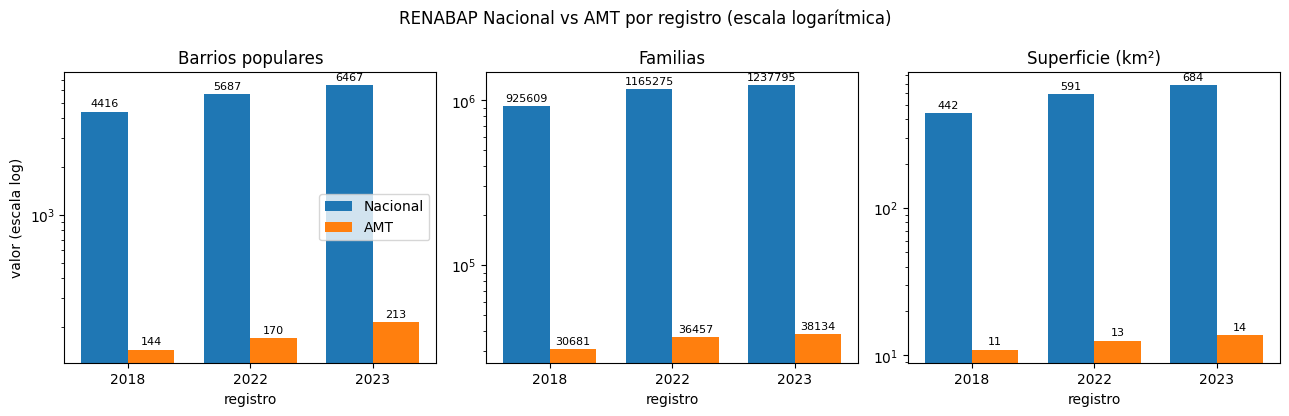

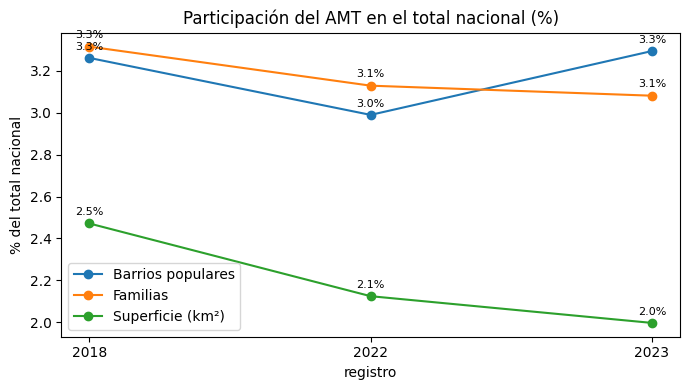

NACIONAL:
           barrios   familias  superficie_km2
registro                                    
2018       4416.0   925609.0          442.26
2022       5687.0  1165275.0          591.11
2023       6467.0  1237795.0          684.20 

AMT:
           barrios  familias  superficie_km2
registro                                   
2018        144.0   30681.0           10.93
2022        170.0   36457.0           12.56
2023        213.0   38134.0           13.67 

Participación AMT (%):
           barrios  familias  superficie_km2
registro                                   
2018         3.26      3.31            2.47
2022         2.99      3.13            2.12
2023         3.29      3.08            2.00


In [62]:
# ============================================================
# CELDA 9B — Comparación gráfica Nacional vs AMT (2018 / 2022 / 2023)
# Métricas: barrios, familias, superficie (km²)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

for _v in ("maestra", "maestra_amt"):
    if _v not in globals():
        raise NameError(f"Falta '{_v}'. Corré la CELDA 5 y el Bloque 2 antes de esta.")

ANIOS = [2018, 2022, 2023]

def totales(df):
    return df.groupby("registro").agg(
        barrios=("id_renabap", "count"),
        familias=("cant_familias", "sum"),
        superficie_km2=("superficie_km2", "sum"),
    ).reindex(ANIOS).astype(float)

nac = totales(maestra)
amt = totales(maestra_amt)

METRICAS = [("barrios", "Barrios populares"),
            ("familias", "Familias"),
            ("superficie_km2", "Superficie (km²)")]

x = np.arange(len(ANIOS))
w = 0.38

# --- Figura 1: absolutos Nacional vs AMT (escala log por la diferencia de magnitud) ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (col, titulo) in zip(axes, METRICAS):
    b1 = ax.bar(x - w/2, nac[col], w, label="Nacional")
    b2 = ax.bar(x + w/2, amt[col], w, label="AMT")
    ax.set_yscale("log")
    ax.set_title(titulo)
    ax.set_xticks(x); ax.set_xticklabels(ANIOS); ax.set_xlabel("registro")
    ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
    ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
axes[0].set_ylabel("valor (escala log)")
axes[0].legend()
fig.suptitle("RENABAP Nacional vs AMT por registro (escala logarítmica)")
plt.tight_layout(); plt.show()

# --- Figura 2: participación del AMT en el total nacional (%) ---
share = amt / nac * 100
fig2, ax = plt.subplots(figsize=(7, 4))
for col, titulo in METRICAS:
    ax.plot(x, share[col], marker="o", label=titulo)
    for xi, yi in zip(x, share[col]):
        ax.annotate(f"{yi:.1f}%", (xi, yi), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=8)
ax.set_title("Participación del AMT en el total nacional (%)")
ax.set_xticks(x); ax.set_xticklabels(ANIOS); ax.set_xlabel("registro")
ax.set_ylabel("% del total nacional"); ax.legend()
plt.tight_layout(); plt.show()

# Números exactos de apoyo
print("NACIONAL:\n", nac.round(2), "\n\nAMT:\n", amt.round(2), "\n\nParticipación AMT (%):\n", share.round(2))



In [63]:
import pandas as pd
import unicodedata


def normalizar(x):
    """minúscula, sin acentos y sin espacios extra — para poder unir por nombre."""
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = "".join(c for c in unicodedata.normalize("NFKD", x) if not unicodedata.combining(c))
    return x


In [64]:
# CELDA 10
nuevas = pd.DataFrame({
    "localidad": ["Colombres", "Delfín Gallo", "Ingenio La Florida",
                  "Los Nogales", "Lastenia", "Ranchillos"],
    "primer_registro": [2022, 2022, 2022, 2022, 2023, 2023],
})

indec_nombre = {
    "Colombres": "Colombres",
    "Delfín Gallo": "Delfín Gallo",
    "Ingenio La Florida": "La Florida",          # INDEC la registra como "La Florida" (incluye el Ingenio)
    "Los Nogales": "Los Nogales",
    "Lastenia": "Lastenia",                      # verificar: puede figurar dentro de otro gobierno local
    "Ranchillos": "Ranchillos",     # nombre completo del gobierno local en INDEC
}
poblacion_2022 = {
    "Colombres": 6325,
    "Delfín Gallo": 10613,
    "Ingenio La Florida": 5002,   # "La Florida": 5.959 en 2010 -> completar con 2022
    "Los Nogales": 5188,
    "Lastenia": None,             # completar (ver nota de matching)
    "Ranchillos": 8844,
}



In [65]:
# CELDA 11
dep = maestra_amt[["localidad", "departamento"]].copy()
dep["localidad"] = dep["localidad"].astype(str).str.strip()
dep = dep.dropna(subset=["departamento"]).drop_duplicates("localidad")

nuevas["localidad"] = nuevas["localidad"].str.strip()
nuevas = nuevas.merge(dep, on="localidad", how="left")   # <- agrega 'departamento'

# 2) Columnas derivadas
def rango(p):
    if pd.isna(p):
        return "sin dato censal"      # Lastenia: parte de la mancha central
    if p < 2000:
        return "< 2.000"
    if p <= 10000:
        return "2.000–10.000"
    return "> 10.000"

nuevas["localidad_INDEC"] = nuevas["localidad"].map(indec_nombre)
nuevas["poblacion_2022"]  = nuevas["localidad"].map(poblacion_2022)
nuevas["rango_tamano"]    = nuevas["poblacion_2022"].map(rango)

# 3) Notas (criterio: localidad = asentamiento censal / mancha urbana)
notas = {
    "Lastenia": ("Sin dato censal como localidad propia: integra la mancha del Gran SMT "
                 "(componente Banda del Río Salí). RENABAP la registra como localidad; "
                 "por hipótesis, dentro del rango 2.000–10.000 (ampliación del universo)."),
    "Ingenio La Florida": "INDEC la registra como 'La Florida' (incluye el Ingenio).",
    "Ranchillos": "Localidad censal 'Ranchillos y San Miguel'.",
}
nuevas["nota"] = nuevas["localidad"].map(notas).fillna("")

# 4) Tabla final
cols = ["localidad", "localidad_INDEC", "departamento",
        "primer_registro", "poblacion_2022", "rango_tamano", "nota"]
tabla = (nuevas[cols]
         .sort_values(["primer_registro", "localidad"])
         .reset_index(drop=True))

print(tabla.to_string(index=False))

from google.colab import data_table

data_table.DataTable(tabla, include_index=False)

         localidad localidad_INDEC departamento  primer_registro  poblacion_2022    rango_tamano                                                                                                                                                                                                               nota
         Colombres       Colombres    Cruz Alta             2022          6325.0    2.000–10.000                                                                                                                                                                                                                   
      Delfín Gallo    Delfín Gallo    Cruz Alta             2022         10613.0        > 10.000                                                                                                                                                                                                                   
Ingenio La Florida      La Florida    Cruz Alta             2022          50

,localidad,localidad_INDEC,departamento,primer_registro,poblacion_2022,rango_tamano,nota
0,Colombres,Colombres,Cruz Alta,2022,6325.0,2.000–10.000,
1,Delfín Gallo,Delfín Gallo,Cruz Alta,2022,10613.0,> 10.000,
2,Ingenio La Florida,La Florida,Cruz Alta,2022,5002.0,2.000–10.000,INDEC la registra como 'La Florida' (incluye e...
3,Los Nogales,Los Nogales,Tafí Viejo,2022,5188.0,2.000–10.000,
4,Lastenia,Lastenia,Cruz Alta,2023,NaN,sin dato censal,Sin dato censal como localidad propia: integra...
5,Ranchillos,Ranchillos,Cruz Alta,2023,8844.0,2.000–10.000,Localidad censal 'Ranchillos y San Miguel'.


In [66]:
# CELDA 12
tabla.to_csv("localidades_nuevas_poblacion_indec2022.csv", index=False, encoding="utf-8-sig")
tabla.to_excel("localidades_nuevas_poblacion_indec2022.xlsx", index=False)
print("Exportado: CSV y XLSX")


Exportado: CSV y XLSX


In [67]:
# CELDA 13
# RENABAP · Análisis comparativo AMT (2018 / 2022 / 2023)
# BLOQUE 3: EDA + comparación entre relevamientos
# Requiere: 'maestra_amt' en memoria (sale del Bloque 2, recorte AMT).

import numpy as np
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt


def normalizar(x):
       if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", x) if not unicodedata.combining(c))




In [72]:
# CELDA 14 — Los dos sets: núcleo (>10.000) vs ampliado (todo)
# ============================================================
# Localidades incorporadas por ampliación del universo registrado.
# Incluye los dos CASOS ESPECIALES (Delfín Gallo: apenas sobre 10.000 en 2022,
# posterior a los relevamientos; Lastenia: sin dato censal como localidad propia).
LOCALIDADES_AGREGADAS = [
    "Colombres", "Delfín Gallo", "Ingenio La Florida",
    "Los Nogales", "Lastenia", "Ranchillos",
]
CASOS_ESPECIALES = ["Delfín Gallo", "Lastenia"]

_agregadas = {normalizar(l) for l in LOCALIDADES_AGREGADAS}
_especiales = {normalizar(l) for l in CASOS_ESPECIALES}

df = maestra_amt.copy()
df["localidad"] = df["localidad"].astype(str).str.strip()
_loc_norm = df["localidad"].map(normalizar)

df["grupo"] = np.where(_loc_norm.isin(_agregadas), "agregada", "núcleo")
df["caso_especial"] = _loc_norm.isin(_especiales)   # marca DG y Lastenia sin partir el análisis

# Los dos sets :
df_ampliado = df.copy()
df_nucleo   = df[df["grupo"] == "núcleo"].copy()

print("Barrios por registro y grupo:")
print(pd.crosstab(df["registro"], df["grupo"], margins=True))


Barrios por registro y grupo:
grupo     agregada  núcleo  All
registro                       
2018             0     144  144
2022             6     164  170
2023            17     196  213
All             23     504  527


In [74]:
# CELDA 5
# Comparación entre relevamientos (núcleo vs ampliado)
# Totales por registro y grupo
from google.colab import data_table

agg = {"barrios": ("id_renabap", "count"), "familias": ("cant_familias", "sum")}
if "cant_viviendas" in df.columns:
    agg["viviendas"] = ("cant_viviendas", "sum")

resumen = df.groupby(["registro", "grupo"]).agg(**agg)


# viviendas: anular años sin dato (2018) para no mostrar un 0 engañoso
if "viviendas" in resumen.columns:
    cobertura = df.groupby("registro")["cant_viviendas"].apply(lambda s: s.notna().any())
    for reg, hay in cobertura.items():
        if not hay:
            resumen.loc[(reg, slice(None)), "viviendas"] = np.nan

print("=== Totales por registro y grupo ===")
print(resumen, "\n")

# Barrios por localidad y registro (excluye localidad vacía)
sin_loc = _loc_norm == ""
if sin_loc.any():
    print(f"[nota] {sin_loc.sum()} barrios sin 'localidad' quedan fuera del detalle por localidad "
          f"(sí cuentan en los totales).\n")

pivot_barrios = (df[~sin_loc]
                 .pivot_table(index="localidad", columns="registro",
                              values="id_renabap", aggfunc="count", fill_value=0))
pivot_barrios["grupo"] = np.where(
    pivot_barrios.index.map(normalizar).isin(_agregadas), "agregada", "núcleo")
print("=== Barrios por localidad y registro ===")
print(pivot_barrios.sort_values(["grupo"] + list(pivot_barrios.columns[:-1]),
                                ascending=[True] + [False] * (pivot_barrios.shape[1] - 1))
      .to_string())


=== Totales por registro y grupo ===
                   barrios  familias  viviendas
registro grupo                                 
2018     núcleo        144     30681        NaN
2022     agregada        6       227      206.0
         núcleo        164     36230    32925.0
2023     agregada       17       749      678.0
         núcleo        196     37385    33973.0 

=== Barrios por localidad y registro ===
registro                                                       2018  2022  2023     grupo
localidad                                                                                
Los Nogales                                                       0     2     4  agregada
Ingenio La Florida                                                0     2     2  agregada
Colombres                                                         0     1     3  agregada
Delfín Gallo                                                      0     1     3  agregada
Ranchillos                                  

registro,2018,2022,2023,grupo
localidad,,,,
Alderetes,12,14,20,núcleo
Banda Del Río Salí,9,9,12,núcleo
Barrio San Felipe,2,2,6,núcleo
Barrio San José III,4,4,4,núcleo
Colombres,0,1,3,agregada
Delfín Gallo,0,1,3,agregada
"Diagonal Norte, Luz Y Fuerza, Los Pocitos, Villa Nueva Italia",4,4,4,núcleo
El Manantial,10,12,14,núcleo
Ingenio La Florida,0,2,2,agregada


=== Barrios por registro ===
registro
2018    144
2022    170
2023    213
Name: barrios, dtype: int64 

=== % de datos faltantes por columna y registro ===
registro          2018   2022   2023
localidad          0.0    0.0    0.0
cant_familias      0.0    0.0    0.0
superficie_km2     0.0    0.0    0.0
anio_creacion     42.4  100.0  100.0
decada_creacion   42.4    0.0    0.0
cant_viviendas   100.0    0.0    0.0 

=== Estadísticos por registro ===

-- cant_familias --
          count    mean     std   min    50%     max
registro                                            
2018      144.0  213.06  308.38  10.0  110.0  2500.0
2022      170.0  214.45  317.44   9.0  114.5  2750.0
2023      213.0  179.03  285.33   9.0   94.0  2750.0

-- cant_viviendas --
          count    mean     std  min    50%     max
registro                                           
2018        0.0     NaN     NaN  NaN    NaN     NaN
2022      170.0  194.89  288.61  8.0  104.0  2500.0
2023      213.0  162.68  259.41  

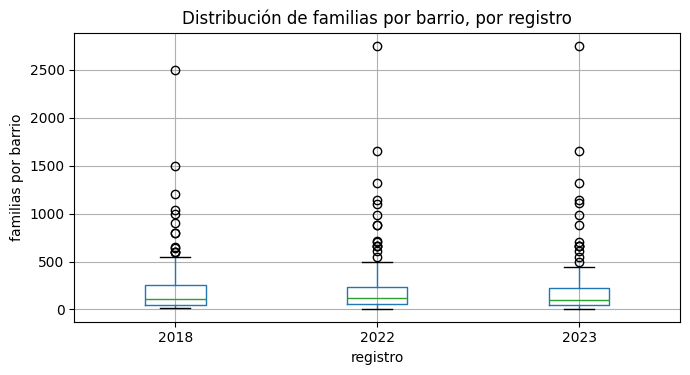

In [73]:
# CELDA 15
# EDA set de datos completo (ampliado): volumen, faltantes, estadísticos
# columnas numéricas disponibles
NUM = [c for c in ["cant_familias", "cant_viviendas", "superficie_km2"] if c in df.columns]
CHK = ["localidad", "cant_familias", "superficie_km2", "anio_creacion", "decada_creacion"]
CHK += [c for c in ["cant_viviendas"] if c in df.columns]

print("=== Barrios por registro ===")
print(df.groupby("registro").size().rename("barrios"), "\n")

def pct_faltante(s):
    """% de NaN + strings vacíos (RENABAP a veces trae '' en vez de NaN)."""
    vacio = s.isna() | (s.astype(str).str.strip() == "")
    return round(100 * vacio.mean(), 1)

faltantes = df.groupby("registro").agg({c: pct_faltante for c in CHK}).T
print("=== % de datos faltantes por columna y registro ===")
print(faltantes, "\n")

print("=== Estadísticos por registro ===")
for c in NUM:
    print(f"\n-- {c} --")
    est = df.assign(**{c: df[c].astype("float")}).groupby("registro")[c] \
            .describe()[["count", "mean", "std", "min", "50%", "max"]]
    print(est.round(2))


# --- Gráfico 2: distribución de familias por barrio ---
df.assign(cant_familias=df["cant_familias"].astype("float")) \
  .boxplot(column="cant_familias", by="registro", figsize=(7, 4))
plt.title("Distribución de familias por barrio, por registro")
plt.suptitle(""); plt.ylabel("familias por barrio"); plt.xlabel("registro")
plt.tight_layout(); plt.show()


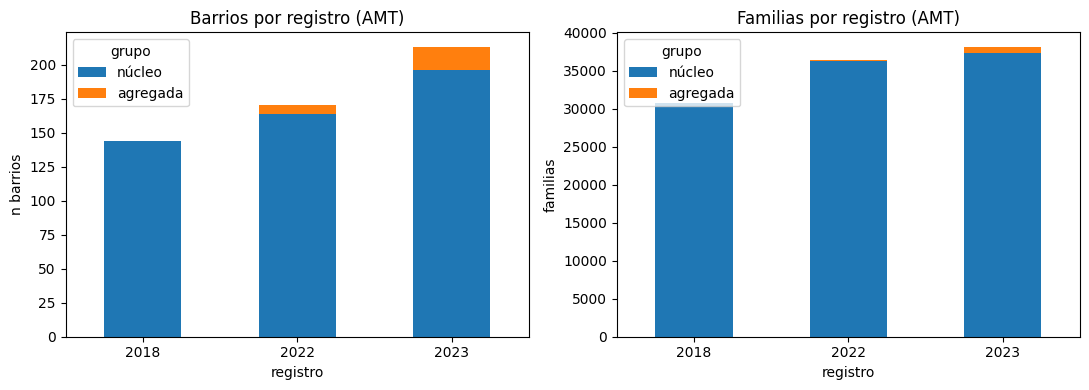

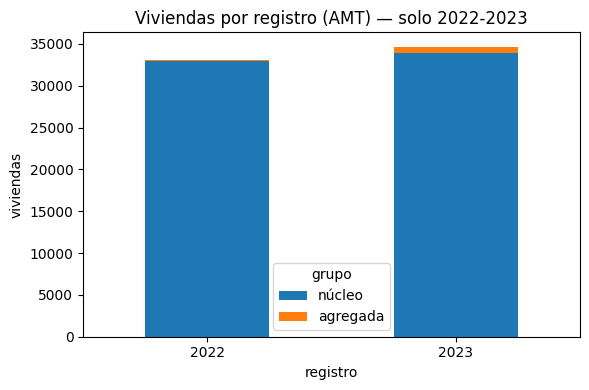

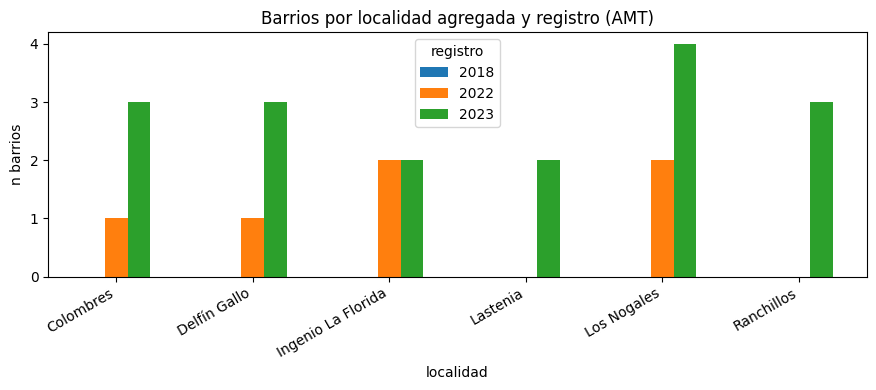

In [71]:
# CELDA 16
# Gráficos comparativos
def barras_apiladas(col, titulo, ylabel, ax):
    """Apila núcleo + agregadas para ver cuánto del total es ampliación del universo."""
    piv = resumen[col].unstack("grupo")
    for g in ["núcleo", "agregada"]:
        if g not in piv.columns:
            piv[g] = np.nan
    piv[["núcleo", "agregada"]].plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(titulo); ax.set_xlabel("registro"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

# Barrios y familias tienen los tres años
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
barras_apiladas("barrios",  "Barrios por registro (AMT)",  "n barrios",  axes[0])
barras_apiladas("familias", "Familias por registro (AMT)", "familias",   axes[1])
plt.tight_layout(); plt.show()

# Viviendas: solo 2022-2023 (2018 no lo releva)
if "viviendas" in resumen.columns:
    piv_v = resumen["viviendas"].unstack("grupo").dropna(how="all")
    for g in ["núcleo", "agregada"]:
        if g not in piv_v.columns:
            piv_v[g] = np.nan
    ax = piv_v[["núcleo", "agregada"]].plot(kind="bar", stacked=True, figsize=(6, 4))
    ax.set_title("Viviendas por registro (AMT) — solo 2022-2023")
    ax.set_xlabel("registro"); ax.set_ylabel("viviendas"); ax.tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()
else:
    print("[viviendas] columna ausente: aplicá el parche del Bloque 1 y re-corré para incluirla.")

# Detalle: barrios por localidad AGREGADA (cómo se van sumando)
agg_piv = pivot_barrios[pivot_barrios["grupo"] == "agregada"].drop(columns="grupo")
if not agg_piv.empty:
    agg_piv.plot(kind="bar", figsize=(9, 4))
    plt.title("Barrios por localidad agregada y registro (AMT)")
    plt.ylabel("n barrios"); plt.xlabel("localidad")
    plt.xticks(rotation=30, ha="right"); plt.legend(title="registro")
    plt.tight_layout(); plt.show()
